In [97]:
import sys
import os

# Adjust this to point to the directory containing the "reproduce_paper" folder
project_root = os.path.abspath("..")  # Or "../.." depending on where the notebook is
if project_root not in sys.path:
    sys.path.insert(0, project_root)

In [98]:



sys.path.append("benchmarks/vae")
from datetime import datetime
from functools import partial
from pathlib import Path
from typing import Callable, Optional, Union

import arviz as az
import flax.linen as nn
import geopandas as gpd
import jax.numpy as jnp
import numpyro
import optax
import pandas as pd
from jax import Array, jit, random
from numpyro import distributions as dist
from numpyro.infer import MCMC, NUTS, Predictive, init_to_median

In [99]:
import sys
from reproduce_paper.deep_rv_plots import (
    plot_models_predictive_means,
    plot_posterior_predictive_comparisons,
)
from reproduce_paper.deep_rv_plots import (
    plot_models_predictive_means,
    plot_posterior_predictive_comparisons,
)
from shapely.affinity import scale, translate
from sps.kernels import matern_1_2, matern_3_2, matern_5_2, rbf
from utils.plot_utils import plot_infer_trace

import wandb
from dl4bi.core.model_output import VAEOutput
from dl4bi.core.train import cosine_annealing_lr, evaluate, train
from dl4bi.vae import MLPDeepRV, TransformerDeepRV, gMLPDeepRV
from dl4bi.vae.train_utils import deep_rv_train_step, generate_surrogate_decoder

In [100]:
def hmc(
    rng: Array,
    model: Callable,
    y_obs: Array,
    surrogate_decoder: Optional[Callable] = None,
    obs_mask: Union[Array, bool] = True,
):
    """runs HMC on given inference model and observed f"""
    nuts = NUTS(model, init_strategy=init_to_median(num_samples=10))
    k1, k2 = random.split(rng)
    mcmc = MCMC(nuts, num_chains=4, num_samples=10_000, num_warmup=4_000)
    # mcmc = MCMC(nuts, num_chains=1, num_samples=10_00, num_warmup=4_00)
    start = datetime.now()
    mcmc.run(k1, surrogate_decoder=surrogate_decoder, y=y_obs, obs_mask=obs_mask)
    infer_time = (datetime.now() - start).total_seconds()
    mcmc.print_summary()
    samples = mcmc.get_samples()
    post = Predictive(model, samples)(k2)
    return samples, mcmc, post, infer_time


def surrogate_model_train(
    rng_train: Array,
    rng_test: Array,
    loader: Callable,
    model: nn.Module,
    optimizer,
    train_num_steps: int = 100_000,
    valid_interval: int = 25_000,
    valid_steps: int = 5_000,
):
    start = datetime.now()
    state = train(
        rng_train,
        model,
        optimizer,
        partial(deep_rv_train_step, var_idx=0),
        train_num_steps,
        loader,
        valid_step,
        valid_interval,
        valid_steps,
        loader,
        return_state="best",
        valid_monitor_metric="norm MSE",
    )
    train_time = (datetime.now() - start).total_seconds()
    eval_mse = evaluate(rng_test, state, valid_step, loader, valid_steps)["norm MSE"]
    surrogate_decoder = generate_surrogate_decoder(state, model)
    return train_time, eval_mse, surrogate_decoder


def gen_train_dataloader(s: Array, priors: dict, kernel: Callable, batch_size=32):
    jitter = 5e-4 * jnp.eye(s.shape[0])
    kernel_jit = jit(lambda s, var, ls: kernel(s, s, var, ls) + jitter)
    f_jit = jit(lambda K, z: jnp.einsum("ij,bj->bi", jnp.linalg.cholesky(K), z))

    def dataloader(rng_data):
        while True:
            rng_data, rng_ls, rng_z = random.split(rng_data, 3)
            var = 1.0
            ls = priors["ls"].sample(rng_ls)
            z = dist.Normal().sample(rng_z, sample_shape=(batch_size, s.shape[0]))
            K = kernel_jit(s, var, ls)
            f = f_jit(K, z)
            yield {"s": s, "f": f, "z": z, "conditionals": jnp.array([ls])}

    return dataloader


def inference_model(s: Array, priors: dict, kernel: Callable, population: Array):
    """
    Builds a Binomial inference model for either actual GP or a surrogate.

    Args:
        s: Locations (n, dim_s).
        population: array of population per location N

    Returns:
        A NumPyro model function, and the parameter names
    """
    surrogate_kwargs = {"s": s}

    def binomial(surrogate_decoder=None, obs_mask=True, y=None):
        var = numpyro.sample("var", priors["var"], sample_shape=())
        ls = numpyro.sample("ls", priors["ls"], sample_shape=())
        beta = numpyro.sample("beta", priors["beta"], sample_shape=())
        if surrogate_decoder:  # whether to use a replacment for the GP
            z = numpyro.sample("z", dist.Normal(), sample_shape=(1, s.shape[0]))
            mu = numpyro.deterministic(
                "mu",
                surrogate_decoder(z, jnp.array([ls]), **surrogate_kwargs).squeeze(),
            )
        else:
            K = kernel(s, s, var, ls) + 5e-4 * jnp.eye(s.shape[0])
            mu = numpyro.sample("mu", dist.MultivariateNormal(0.0, K))
        eta = jnp.sqrt(var) * mu + beta
        with numpyro.handlers.mask(mask=obs_mask):
            numpyro.sample("obs", dist.Binomial(population, logits=eta), obs=y)

    return binomial, ["var", "ls", "beta"]


@jit
def valid_step(rng, state, batch):
    output: VAEOutput = state.apply_fn(
        {"params": state.params, **state.kwargs}, **batch, rngs={"extra": rng}
    )
    metrics = output.metrics(batch["f"], 1.0)
    return {"norm MSE": metrics["MSE"]}


def gen_spatial_structure(map_data: gpd.GeoDataFrame, s_max=100):
    """generates a 0-s_max range locations from the geo-locations centroids"""
    centroids = map_data.geometry.centroid
    minx, maxx = centroids.x.min(), centroids.x.max()
    miny, maxy = centroids.y.min(), centroids.y.max()
    x_tran, x_div = minx, (maxx - minx) / s_max
    y_tran, y_div = miny, (maxy - miny) / s_max

    def norm_geom(geom):
        centered_geom = translate(geom, xoff=-x_tran, yoff=-y_tran)
        normalized_geom = scale(
            centered_geom, xfact=1 / x_div, yfact=1 / y_div, origin=(0, 0)
        )
        return normalized_geom

    norm_map = map_data.copy()
    norm_map["geometry"] = norm_map.geometry.apply(norm_geom)
    centroids = norm_map.geometry.centroid
    return jnp.stack([centroids.x.values, centroids.y.values], axis=-1)



In [102]:
print(os.listdir("../maps/Selena_1k_grid"))

['grid_1000m.shp', 'grid_1000m.cpg', 'grid_1000m.shx', 'grid_1000m.dbf']


In [ ]:
seed=42
wandb.init(mode="disabled")
rng = random.key(seed)
rng_train, rng_test, rng_infer = random.split(rng, 3)
kernel = matern_1_2  # NOTE: choose from: matern_1_2, matern_3_2, matern_5_2, rbf
save_dir = Path(f"results/orphan_dataset/{kernel.__name__}")
save_dir.mkdir(parents=True, exist_ok=True)
# NOTE: change to the correct path for you
map_data = gpd.read_file("../maps/Selena_1k_grid")

 
# NOTE: specifically for 2k grid - these location are an outlier
map_data = map_data.drop(index=[316, 317, 318, 319]).reset_index(drop=True)
s = gen_spatial_structure(map_data)
L = s.shape[0]
models = {
    # "Baseline_GP": None,  # Baseline test - can remove if takes too long
    "DeepRV + MLP": MLPDeepRV(dims=[L, L]),
    # "DeepRV + gMLP": gMLPDeepRV(num_blks=2),
    # "DeepRV + Transfomer": TransformerDeepRV(num_blks=2, dim=64),
}

# NOTE: change to correct data columns paternal\maternal etc
y_obs = jnp.array(map_data.paternal, dtype=jnp.float32)
population = jnp.array(map_data.childtotal, dtype=jnp.int32)
obs_mask = jnp.array(map_data.observed == 1, dtype=jnp.bool)
priors = {
    "var": dist.Gamma(1.5, 1.5),
    "ls": dist.InverseGamma(3.0, 3.0),
    "beta": dist.Normal(),  # NOTE: intercept
}
binom_infer_model, cond_names = inference_model(s, priors, kernel, population)
loader = gen_train_dataloader(s, priors, kernel)
y_hats, all_samples, result = [y_obs], [], []

In [104]:
map_data

,lat,lon,childtotal,maternal,paternal,double,any,observed,geometry
0,0.007299,0.084967,4.0,0.0,0.0,0.0,0.0,1,"POLYGON ((0.0817 0.00547, 0.0817 0.00912, 0.08..."
1,0.007299,0.091503,14.0,1.0,1.0,1.0,1.0,1,"POLYGON ((0.08824 0.00547, 0.08824 0.00912, 0...."
2,0.007299,0.098039,2.0,0.0,0.0,0.0,0.0,1,"POLYGON ((0.09477 0.00547, 0.09477 0.00912, 0...."
3,0.007299,0.104575,10.0,0.0,0.0,0.0,0.0,1,"POLYGON ((0.10131 0.00547, 0.10131 0.00912, 0...."
4,0.010949,0.078431,3.0,0.0,0.0,0.0,0.0,1,"POLYGON ((0.07516 0.00912, 0.07516 0.01277, 0...."
...,...,...,...,...,...,...,...,...,...
2373,0.043796,0.130719,NaN,NaN,NaN,NaN,NaN,0,"POLYGON ((0.12745 0.04197, 0.12745 0.04562, 0...."
2374,0.043796,0.137255,NaN,NaN,NaN,NaN,NaN,0,"POLYGON ((0.13399 0.04197, 0.13399 0.04562, 0...."
2375,0.047445,0.111111,NaN,NaN,NaN,NaN,NaN,0,"POLYGON ((0.10784 0.04562, 0.10784 0.04927, 0...."
2376,0.047445,0.117647,NaN,NaN,NaN,NaN,NaN,0,"POLYGON ((0.11438 0.04562, 0.11438 0.04927, 0...."


In [105]:
for model_name, model in models.items():
    optimizer = optax.yogi(cosine_annealing_lr(100_000, 5.0e-3, lr_min=0.0))
    if model_name == "DeepRV + ScanTransfomer":
        optimizer = optax.adamw(5.0e-4)
    train_time, eval_mse, surrogate_decoder = None, None, None
    if model_name != "Baseline_GP":
        # NOTE: Train the surrogate
        train_time, eval_mse, surrogate_decoder = surrogate_model_train(
            rng_train, rng_test, loader, model, optimizer
        )
    # NOTE: Run inference
    samples, mcmc, post, infer_time = hmc(
        rng_infer, binom_infer_model, y_obs, surrogate_decoder, obs_mask
    )
    y_hats.append(post["obs"])
    all_samples.append(samples)
    ess = az.ess(mcmc, method="mean")
    plot_infer_trace(
        samples, mcmc, None, cond_names, save_dir / f"{model_name}_infer_trace.png"
    )
    result.append(
        {
            "model_name": model_name,
            "train_time": train_time,
            "Test Norm MSE": eval_mse,
            "infer_time": infer_time,
            "inferred lengthscale mean": samples["ls"].mean(axis=0),
            "inferred fixed effects": samples["beta"].mean(axis=0),
            "inferred variance": samples["var"].mean(axis=0),
            "MSE(y, y_hat)": ((y_obs - post["obs"].mean(axis=0)) ** 2).mean(),
            "ESS spatial effects": ess["mu"].mean().item(),
            "ESS lengthscale": ess["ls"].item(),
            "ESS variance": ess["var"].item(),
            "ESS fixed effects": ess["beta"].item(),
        }
    )
plot_posterior_predictive_comparisons(
    all_samples, {}, priors, list(models.keys()), cond_names, save_dir / "comp"
)
# NOTE: plots the observed means by the order of the models above
f_hat_means, vmin, vmax = plot_models_predictive_means(y_hats, map_data, save_dir / "obs_means.png")

result.append(
    {
        "vmin": vmin,
        "vmax": vmax,
    }
)






                               MLPDeepRV Summary                                
┏━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┓
┃ path           ┃ module    ┃ inputs         ┃ outputs       ┃ params         ┃
┡━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━┩
│                │ MLPDeepRV │ conditionals:  │ VAEOutput(f_… │                │
│                │           │ float32[1]     │ encoder_outp… │                │
│                │           │ f:             │               │                │
│                │           │ float32[32,23… │               │                │
│                │           │ s:             │               │                │
│                │           │ float32[2378,… │               │                │
│                │           │ z:             │               │                │
│                │           │ float32[32,23… │               │                │
├────────────────┼─────────

100%|██████████| 100000/100000 [2:31:45<00:00, 10.98batch/s, Train Loss=0.0488, Valid norm MSE=0.0681]     
/var/folders/f9/6qm__g0x43z2c3q6_6g_q9cc0000gn/T/ipykernel_42969/1558199121.py:11: UserWarning: There are not enough devices to run parallel chains: expected 4 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(4)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = MCMC(nuts, num_chains=4, num_samples=10_000, num_warmup=4_000)
sample: 100%|██████████| 14000/14000 [17:38:30<00:00,  4.54s/it, 63 steps of size 6.93e-02. acc. prob=0.86]     



                mean       std    median      5.0%     95.0%     n_eff     r_hat
      beta     -2.54      0.42     -2.54     -3.23     -1.85  17325.95      1.00
        ls      2.64      1.14      2.37      1.10      4.27   8713.46      1.00
       var      5.25      0.93      5.17      3.71      6.71  18880.44      1.00
    z[0,0]     -0.74      0.72     -0.71     -1.94      0.42  41821.59      1.00
    z[0,1]      0.05      0.64      0.08     -1.00      1.08  46719.08      1.00
    z[0,2]     -0.60      0.85     -0.58     -2.02      0.78  58913.16      1.00
    z[0,3]     -0.54      0.79     -0.51     -1.79      0.79  55068.02      1.00
    z[0,4]     -0.31      0.82     -0.27     -1.66      1.03  55439.34      1.00
    z[0,5]     -0.33      0.87     -0.31     -1.81      1.05  62283.20      1.00
    z[0,6]     -0.30      0.91     -0.28     -1.78      1.21  67191.10      1.00
    z[0,7]      0.01      0.87      0.02     -1.41      1.42  54895.61      1.00
    z[0,8]     -0.07      0

In [106]:
f_hat_means

[Array([0.       , 0.6931472, 0.       , ...,       nan,       nan,
              nan], dtype=float32),
 Array([0.09042452, 0.40184948, 0.0500451 , ..., 0.        , 0.        ,
        0.        ], dtype=float32)]

In [107]:
for i, f_mean in enumerate(f_hat_means):
    map_data["TEMP"] = f_mean

In [108]:
map_data

,lat,lon,childtotal,maternal,paternal,double,any,observed,geometry,TEMP
0,0.007299,0.084967,4.0,0.0,0.0,0.0,0.0,1,"POLYGON ((0.0817 0.00547, 0.0817 0.00912, 0.08...",0.090425
1,0.007299,0.091503,14.0,1.0,1.0,1.0,1.0,1,"POLYGON ((0.08824 0.00547, 0.08824 0.00912, 0....",0.401849
2,0.007299,0.098039,2.0,0.0,0.0,0.0,0.0,1,"POLYGON ((0.09477 0.00547, 0.09477 0.00912, 0....",0.050045
3,0.007299,0.104575,10.0,0.0,0.0,0.0,0.0,1,"POLYGON ((0.10131 0.00547, 0.10131 0.00912, 0....",0.141102
4,0.010949,0.078431,3.0,0.0,0.0,0.0,0.0,1,"POLYGON ((0.07516 0.00912, 0.07516 0.01277, 0....",0.083904
...,...,...,...,...,...,...,...,...,...,...
2373,0.043796,0.130719,NaN,NaN,NaN,NaN,NaN,0,"POLYGON ((0.12745 0.04197, 0.12745 0.04562, 0....",0.000000
2374,0.043796,0.137255,NaN,NaN,NaN,NaN,NaN,0,"POLYGON ((0.13399 0.04197, 0.13399 0.04562, 0....",0.000000
2375,0.047445,0.111111,NaN,NaN,NaN,NaN,NaN,0,"POLYGON ((0.10784 0.04562, 0.10784 0.04927, 0....",0.000000
2376,0.047445,0.117647,NaN,NaN,NaN,NaN,NaN,0,"POLYGON ((0.11438 0.04562, 0.11438 0.04927, 0....",0.000000


In [109]:
# pd.DataFrame(result).to_csv(save_dir / "res.csv")

# # save the model predictions with the corresponding map data
# map_data["y_preds"] = f_hat_means
# y_preds = []
# y_preds.append(
#     {
#         "y_preds": f_hat_means,
#     }
# )

# # save f_hat_means, vmin, vmax to a GeoDataFrame and then save it
# pd.DataFrame(y_preds).to_csv(save_dir / "y_preds") 


In [ ]:
!pip install fiona
!pip install geopy

import pandas as pd
import geopandas as gpd
import fiona as fiona
import os
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN
from geopy.distance import distance
from geopy.distance import geodesic
from shapely.geometry import Polygon, Point
from sklearn.metrics import pairwise_distances
from math import ceil



In [ ]:
print(os.getcwd())

In [112]:
# Load the shapefile using geopandas
shapefile_path = '../../../Shapefiles/zmb_admbnda_adm2_dmmu_20201124.shp'  
adm2_region = gpd.read_file(shapefile_path)
sinazongwe_region = adm2_region[adm2_region['ADM2_EN']=='Sinazongwe']

In [113]:
orphanhood_prev_hh = pd.read_csv('../../../orphanhood_prev_hh')

In [114]:
orphanhood_prev_hh

,Unnamed: 0,lat,long,mat_orph,pat_orph,both_orph,atleast1_orph,mat_total,pat_total,both_total,atleast1_total,total_children,LATNUM,LONGNUM
0,1,-15.412262,28.218528,33.333333,0.000000,0.000000,33.333333,1,0,0,1,3,-15.412262,28.218528
1,2,-15.414888,28.277888,100.000000,100.000000,100.000000,100.000000,1,1,1,1,1,-15.414888,28.277888
2,3,-15.421163,28.246461,100.000000,0.000000,0.000000,100.000000,1,0,0,1,1,-15.421163,28.246461
3,4,-15.421221,28.234018,0.000000,0.000000,0.000000,0.000000,0,0,0,0,1,-15.421221,28.234018
4,5,-16.964455,27.637396,0.000000,0.000000,0.000000,0.000000,0,0,0,0,1,-16.964455,27.637396
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3820,3821,-17.860621,27.026514,33.333333,33.333333,33.333333,33.333333,1,1,1,1,3,-17.860621,27.026514
3821,3822,-17.861259,27.021785,0.000000,0.000000,0.000000,0.000000,0,0,0,0,1,-17.861259,27.021785
3822,3823,-17.861279,27.021786,0.000000,0.000000,0.000000,0.000000,0,0,0,0,1,-17.861279,27.021786
3823,3824,-17.861289,27.021780,0.000000,0.000000,0.000000,0.000000,0,0,0,0,1,-17.861289,27.021780


In [115]:
coords = np.radians(orphanhood_prev_hh[['lat', 'long']].to_numpy())

# Perform DBSCAN with prebuilt haversine metric
kms_per_radian = 6371.0088  # Earth's radius
epsilon = 4 / kms_per_radian  # 5 km radius

db = DBSCAN(eps=epsilon, min_samples=5, algorithm='ball_tree', metric='haversine')
clusters = db.fit_predict(coords)


In [116]:
coords

array([[-0.26899472,  0.49250622],
       [-0.26904055,  0.49354226],
       [-0.26915006,  0.49299375],
       ...,
       [-0.31173813,  0.47161914],
       [-0.31173829,  0.47161904],
       [-0.31173847,  0.47161721]])

In [117]:
# Add cluster labels to the dataframe
orphanhood_prev_hh['cluster'] = clusters

In [118]:
# Find cluster centers
cluster_centers = []
for cluster_id in set(clusters):
    if cluster_id != -1:  # Exclude noise points
        cluster_points = orphanhood_prev_hh[orphanhood_prev_hh['cluster'] == cluster_id][['lat', 'long']]
        center_lat = cluster_points['lat'].mean()
        center_lon = cluster_points['long'].mean()
        cluster_centers.append({'cluster': cluster_id, 'center_lat': center_lat, 'center_lon': center_lon})

cluster_centers_df = pd.DataFrame(cluster_centers)

print("Cluster centers:")
print(cluster_centers_df)

Cluster centers:
   cluster  center_lat  center_lon
0        0  -17.011779   27.649712
1        1  -17.074661   27.532732
2        2  -17.218071   27.466687
3        3  -17.345093   27.407323
4        4  -17.418065   27.249352
5        5  -17.684293   27.029169
6        6  -17.723645   26.930540
7        7  -17.821056   27.063589


In [119]:
def geodesic_cluster_distances(center, points):
    return [geodesic((center['center_lat'], center['center_lon']), (lat, lon)).meters for lat, lon in zip(points['lat'], points['long'])]

In [120]:
# Find minimum radius for each cluster

min_radii = []

for center in cluster_centers:
    center_lat = center['center_lat']
    center_lon = center['center_lon']
    cluster_label = center['cluster']

    cluster_points = orphanhood_prev_hh[orphanhood_prev_hh['cluster'] == cluster_label][['lat', 'long']]

    # Calculate geodesic distances
    distances = geodesic_cluster_distances(center, cluster_points)
    min_radius = max(distances)
    min_radii.append({'cluster_label': cluster_label, 'min_radius': min_radius})

min_radius_dict = {item['cluster_label']: item['min_radius'] for item in min_radii}

min_radius_dict


{np.int64(0): 7599.7470578241555,
 np.int64(1): 9815.660461163263,
 np.int64(2): 11313.660161743179,
 np.int64(3): 844.4248390435698,
 np.int64(4): 18475.531921355025,
 np.int64(5): 7120.692569936751,
 np.int64(6): 2518.7024300573016,
 np.int64(7): 6503.327891474927}

In [121]:
ceil(min_radius_dict[5])

7121

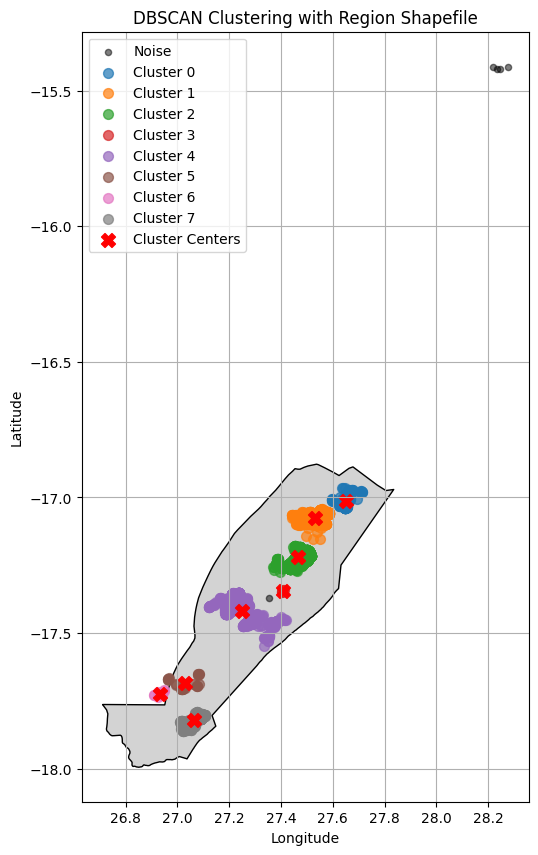

In [122]:
# Step 6: Plot the results
fig, ax = plt.subplots(figsize=(10, 10))

# Plot the shapefile (region boundary)
sinazongwe_region.plot(ax=ax, color='lightgrey', edgecolor='black')

# Plot the cluster points
for cluster_id in orphanhood_prev_hh['cluster'].unique():
    cluster_points = orphanhood_prev_hh[orphanhood_prev_hh['cluster'] == cluster_id]
    if cluster_id == -1:  # Noise points
        plt.scatter(cluster_points['long'], cluster_points['lat'], 
                    color='black', label='Noise', s=20, alpha=0.5)
    else:
        plt.scatter(cluster_points['long'], cluster_points['lat'], 
                    label=f'Cluster {cluster_id}', s=50, alpha=0.7)

# Plot cluster centers
plt.scatter(cluster_centers_df['center_lon'], cluster_centers_df['center_lat'], 
            color='red', label='Cluster Centers', s=100, marker='X')

# Add titles and labels
plt.title("DBSCAN Clustering with Region Shapefile")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.grid(True)

# Show the plot
plt.show()

In [123]:
orphanhood_prev_hh

,Unnamed: 0,lat,long,mat_orph,pat_orph,both_orph,atleast1_orph,mat_total,pat_total,both_total,atleast1_total,total_children,LATNUM,LONGNUM,cluster
0,1,-15.412262,28.218528,33.333333,0.000000,0.000000,33.333333,1,0,0,1,3,-15.412262,28.218528,-1
1,2,-15.414888,28.277888,100.000000,100.000000,100.000000,100.000000,1,1,1,1,1,-15.414888,28.277888,-1
2,3,-15.421163,28.246461,100.000000,0.000000,0.000000,100.000000,1,0,0,1,1,-15.421163,28.246461,-1
3,4,-15.421221,28.234018,0.000000,0.000000,0.000000,0.000000,0,0,0,0,1,-15.421221,28.234018,-1
4,5,-16.964455,27.637396,0.000000,0.000000,0.000000,0.000000,0,0,0,0,1,-16.964455,27.637396,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3820,3821,-17.860621,27.026514,33.333333,33.333333,33.333333,33.333333,1,1,1,1,3,-17.860621,27.026514,7
3821,3822,-17.861259,27.021785,0.000000,0.000000,0.000000,0.000000,0,0,0,0,1,-17.861259,27.021785,7
3822,3823,-17.861279,27.021786,0.000000,0.000000,0.000000,0.000000,0,0,0,0,1,-17.861279,27.021786,7
3823,3824,-17.861289,27.021780,0.000000,0.000000,0.000000,0.000000,0,0,0,0,1,-17.861289,27.021780,7


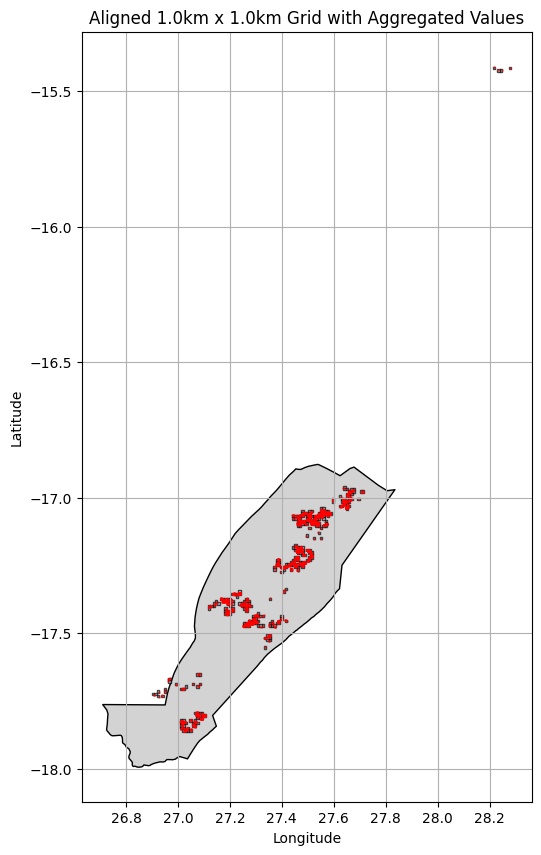

In [124]:
# Step 1: DataFrame with location coordinates

df = pd.read_csv('../../../orphanhood_prev_hh')

# Step 2: Set grid size (in meters) and calculate degrees
pixel_size_meters = 1000  # Desired grid size
deg_per_meter = 1 / 111320  # Approximate degrees per meter (at equator)

grid_spacing_deg = pixel_size_meters * deg_per_meter  # Convert grid size to degrees

# Step 3: Snap coordinates to the grid
def snap_to_grid(lat, lon, grid_spacing):
    snapped_lat = np.round(lat / grid_spacing) * grid_spacing
    snapped_lon = np.round(lon / grid_spacing) * grid_spacing
    return snapped_lat, snapped_lon

# Apply snapping to grid
df[['latitude_snapped', 'longitude_snapped']] = df.apply(
    lambda row: pd.Series(snap_to_grid(row['lat'], row['long'], grid_spacing_deg)),
    axis=1
)

# Step 4: Group by snapped coordinates and aggregate values
aggregated_df_og = df.groupby(['latitude_snapped', 'longitude_snapped'], as_index=False).agg({
    'total_children': 'sum',
   'mat_total': 'sum',
    'pat_total': 'sum',
    'both_total': 'sum',
    'atleast1_total': 'sum'
})

# Step 5: Create adjacent square polygons based on snapped coordinates
def create_square(lat, lon, grid_spacing):
    """Create a square polygon centered at (lat, lon)."""
    half_spacing = grid_spacing / 2
    bottom_left = (lon - half_spacing, lat - half_spacing)
    bottom_right = (lon + half_spacing, lat - half_spacing)
    top_right = (lon + half_spacing, lat + half_spacing)
    top_left = (lon - half_spacing, lat + half_spacing)
    return Polygon([bottom_left, bottom_right, top_right, top_left, bottom_left])

# Generate polygons for each grid center
aggregated_df_og['geometry'] = aggregated_df_og.apply(
    lambda row: create_square(row['latitude_snapped'], row['longitude_snapped'], grid_spacing_deg),
    axis=1
)

# Step 6: Create a GeoDataFrame
gdf = gpd.GeoDataFrame(aggregated_df_og, geometry='geometry', crs="EPSG:4326")

# Step 7: Plot the grid with aggregated values
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))

# Plot the shapefile (region boundary)
sinazongwe_region.plot(ax=ax, color='lightgrey', edgecolor='black')

# Plot polygons
gdf.plot(ax=ax, color='lightblue', edgecolor='black', alpha=0.7)


# Plot the centroids (original points)
gdf_points = gpd.GeoDataFrame(geometry=gpd.points_from_xy(df['long'], df['lat']), crs="EPSG:4326")
gdf_points.plot(ax=ax, color='red', markersize=1, alpha=0.4, label='Centroids')


# Final touches
plt.title(f"Aligned {pixel_size_meters/1000}km x {pixel_size_meters/1000}km Grid with Aggregated Values")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid()
plt.show()

In [125]:
aggregated_df_og

,latitude_snapped,longitude_snapped,total_children,mat_total,pat_total,both_total,atleast1_total,geometry
0,-17.858426,27.021200,4,0,0,0,0,POLYGON ((27.016708587854833 -17.8629177146963...
1,-17.858426,27.030183,14,1,1,1,1,POLYGON ((27.025691699604742 -17.8629177146963...
2,-17.858426,27.039166,2,0,0,0,0,POLYGON ((27.034674811354652 -17.8629177146963...
3,-17.858426,27.048149,10,0,0,0,0,POLYGON ((27.04365792310456 -17.86291771469637...
4,-17.849443,27.012217,3,0,0,0,0,POLYGON ((27.00772547610492 -17.85393460294646...
...,...,...,...,...,...,...,...,...
318,-16.960115,27.641035,1,0,0,0,0,POLYGON ((27.63654329859863 -16.96460653970535...
319,-15.424003,28.233920,1,0,0,0,0,POLYGON ((28.229428674092706 -15.4284944304707...
320,-15.424003,28.242903,1,1,0,0,1,POLYGON ((28.238411785842615 -15.4284944304707...
321,-15.415020,28.215954,3,1,0,0,1,POLYGON ((28.211462450592883 -15.4195113187208...


In [126]:
df

,Unnamed: 0,lat,long,mat_orph,pat_orph,both_orph,atleast1_orph,mat_total,pat_total,both_total,atleast1_total,total_children,LATNUM,LONGNUM,latitude_snapped,longitude_snapped
0,1,-15.412262,28.218528,33.333333,0.000000,0.000000,33.333333,1,0,0,1,3,-15.412262,28.218528,-15.415020,28.215954
1,2,-15.414888,28.277888,100.000000,100.000000,100.000000,100.000000,1,1,1,1,1,-15.414888,28.277888,-15.415020,28.278836
2,3,-15.421163,28.246461,100.000000,0.000000,0.000000,100.000000,1,0,0,1,1,-15.421163,28.246461,-15.424003,28.242903
3,4,-15.421221,28.234018,0.000000,0.000000,0.000000,0.000000,0,0,0,0,1,-15.421221,28.234018,-15.424003,28.233920
4,5,-16.964455,27.637396,0.000000,0.000000,0.000000,0.000000,0,0,0,0,1,-16.964455,27.637396,-16.960115,27.641035
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3820,3821,-17.860621,27.026514,33.333333,33.333333,33.333333,33.333333,1,1,1,1,3,-17.860621,27.026514,-17.858426,27.030183
3821,3822,-17.861259,27.021785,0.000000,0.000000,0.000000,0.000000,0,0,0,0,1,-17.861259,27.021785,-17.858426,27.021200
3822,3823,-17.861279,27.021786,0.000000,0.000000,0.000000,0.000000,0,0,0,0,1,-17.861279,27.021786,-17.858426,27.021200
3823,3824,-17.861289,27.021780,0.000000,0.000000,0.000000,0.000000,0,0,0,0,1,-17.861289,27.021780,-17.858426,27.021200


In [127]:
df[df['long'] > 28]

,Unnamed: 0,lat,long,mat_orph,pat_orph,both_orph,atleast1_orph,mat_total,pat_total,both_total,atleast1_total,total_children,LATNUM,LONGNUM,latitude_snapped,longitude_snapped
0,1,-15.412262,28.218528,33.333333,0.0,0.0,33.333333,1,0,0,1,3,-15.412262,28.218528,-15.415020,28.215954
1,2,-15.414888,28.277888,100.000000,100.0,100.0,100.000000,1,1,1,1,1,-15.414888,28.277888,-15.415020,28.278836
2,3,-15.421163,28.246461,100.000000,0.0,0.0,100.000000,1,0,0,1,1,-15.421163,28.246461,-15.424003,28.242903
3,4,-15.421221,28.234018,0.000000,0.0,0.0,0.000000,0,0,0,0,1,-15.421221,28.234018,-15.424003,28.233920


In [128]:
# Function to compute geodesic distance
def geodesic_distance(lat1, lon1, lat2, lon2):
    """Calculate the geodesic distance between two lat/lon points in meters."""
    return geodesic((lat1, lon1), (lat2, lon2)).meters


# Generate new grid points around cluster centers within a defined radius
def create_grid_within_radius(center_lat, center_lon, radius, grid_spacing):
    """Generate grid points within a certain radius around a center point."""
    grid_points = []
    
    # Create a bounding box around the center (radius in meters)
    lat_min = center_lat - (radius / 111320)  # Approximate conversion for latitude
    lat_max = center_lat + (radius / 111320)
    lon_min = center_lon - (radius / (111320 * np.cos(np.radians(center_lat))))  # Approximate conversion for longitude
    lon_max = center_lon + (radius / (111320 * np.cos(np.radians(center_lat))))  # Approximate conversion for longitude
    
    # Create grid points within the bounding box, snapping to the grid
    latitudes = np.arange(lat_min, lat_max, grid_spacing)
    longitudes = np.arange(lon_min, lon_max, grid_spacing)
    
    for lat in latitudes:
        for lon in longitudes:
            # Check if the point is within the radius from the cluster center
            if geodesic_distance(center_lat, center_lon, lat, lon) <= radius:
                snapped_lat, snapped_lon = snap_to_grid(lat, lon, grid_spacing)
                grid_points.append((snapped_lat, snapped_lon))
    
    return grid_points

# Check if a point is within the Sinazongwe boundary
def is_within_boundary(lat, lon, boundary_gdf):
    """Check if a point (lat, lon) is within the provided boundary."""
    point = Point(lon, lat)  # Shapely expects (lon, lat)
    return boundary_gdf.contains(point).any()

In [129]:
aggregated_df = aggregated_df_og

# Add new grid locations around cluster centers and mark as missing
new_grid_locations = []
boundary_gdf = sinazongwe_region

for cluster_center in cluster_centers:
    center_lat = cluster_center['center_lat']
    center_lon = cluster_center['center_lon']
    radius = min_radius_dict.get(cluster_center['cluster'], None) 
    radius_rounded = int(ceil(radius / 100.0)) * 100 # round up
    grid_points = create_grid_within_radius(center_lat, center_lon, radius_rounded, grid_spacing_deg)
    
    for lat, lon in grid_points:
        if is_within_boundary(lat, lon, boundary_gdf):
            # Check if the grid point already exists in the aggregated_df
            if not((aggregated_df['latitude_snapped'] == lat) & (aggregated_df['longitude_snapped'] == lon)).any():
                new_grid_locations.append({'latitude_snapped': lat, 
                                           'longitude_snapped': lon,
                                          'observed': False})

# Create the new DataFrame for new grid points
new_grid_df = pd.DataFrame(new_grid_locations)

# Add observed column in aggregated_df
aggregated_df['observed'] = True

# Aggregate the new grid points with existing data
aggregated_df = pd.concat([aggregated_df, new_grid_df], ignore_index=True)

# Generate square polygons for new grid locations
aggregated_df['geometry'] = aggregated_df.apply(
    lambda row: create_square(row['latitude_snapped'], row['longitude_snapped'], grid_spacing_deg),
    axis=1
)

print(f"New grid locations added. Total rows: {len(aggregated_df)}")

New grid locations added. Total rows: 2382


/var/folders/f9/6qm__g0x43z2c3q6_6g_q9cc0000gn/T/ipykernel_42969/2960197880.py:35: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()


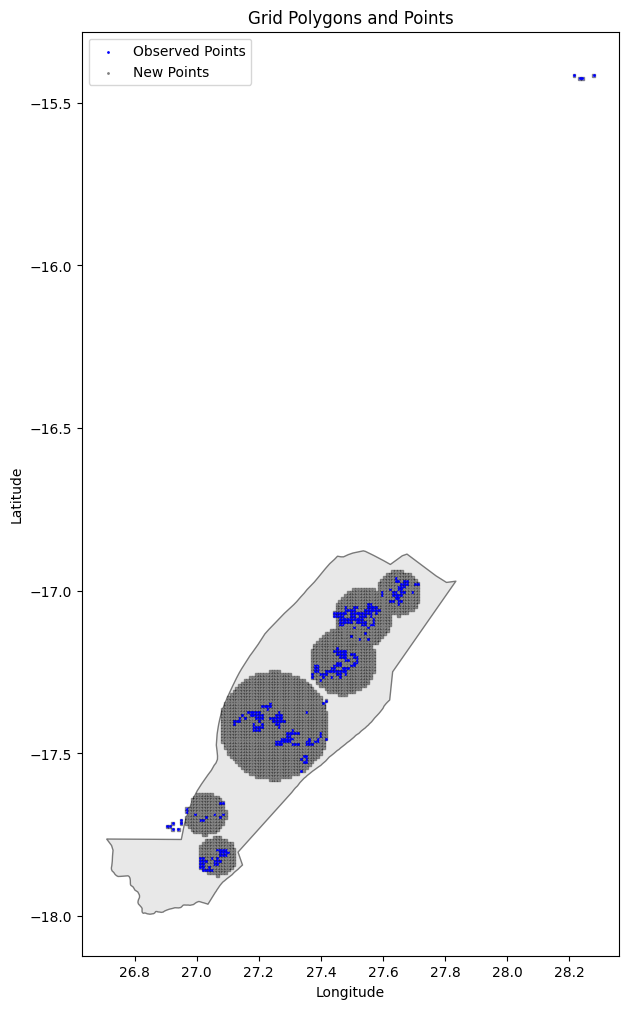

In [130]:
# Plot the boundary first
fig, ax = plt.subplots(figsize=(12, 12))
boundary_gdf.plot(ax=ax, color='lightgrey', edgecolor='black', alpha=0.5)


# Observed grid points
observed_geom = gpd.GeoDataFrame(aggregated_df[aggregated_df['observed'] == True], geometry='geometry', crs="EPSG:4326")
new_geom =  gpd.GeoDataFrame(aggregated_df[aggregated_df['observed'] == False],  geometry='geometry', crs="EPSG:4326")

# Plot observed polygons (blue)
observed_geom.plot(ax=ax, color='blue', edgecolor='black', alpha=0.4, label='Observed Squares')

# Plot new polygons (red)
new_geom.plot(ax=ax, color='grey', edgecolor='black', alpha=0.4, label='New Squares')

# Plot observed points (centroids of polygons)
plt.scatter(
    observed_geom['longitude_snapped'], 
    observed_geom['latitude_snapped'], 
    color='blue', 
    label='Observed Points', 
    s=1
)

# Plot new points (centroids of polygons)
plt.scatter(
    new_geom['longitude_snapped'], 
    new_geom['latitude_snapped'], 
    color='grey', 
    label='New Points', 
    s=1
)

# Add legend and labels
plt.legend()
plt.title('Grid Polygons and Points')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

# Show the plot
plt.show()

In [131]:
aggregated_df

,latitude_snapped,longitude_snapped,total_children,mat_total,pat_total,both_total,atleast1_total,geometry,observed
0,-17.858426,27.021200,4.0,0.0,0.0,0.0,0.0,POLYGON ((27.016708587854833 -17.8629177146963...,True
1,-17.858426,27.030183,14.0,1.0,1.0,1.0,1.0,POLYGON ((27.025691699604742 -17.8629177146963...,True
2,-17.858426,27.039166,2.0,0.0,0.0,0.0,0.0,POLYGON ((27.034674811354652 -17.8629177146963...,True
3,-17.858426,27.048149,10.0,0.0,0.0,0.0,0.0,POLYGON ((27.04365792310456 -17.86291771469637...,True
4,-17.849443,27.012217,3.0,0.0,0.0,0.0,0.0,POLYGON ((27.00772547610492 -17.85393460294646...,True
...,...,...,...,...,...,...,...,...,...
2377,-17.768595,27.084082,NaN,NaN,NaN,NaN,NaN,POLYGON ((27.079590370104203 -17.7730865971972...,False
2378,-17.768595,27.093065,NaN,NaN,NaN,NaN,NaN,POLYGON ((27.088573481854112 -17.7730865971972...,False
2379,-17.759612,27.057133,NaN,NaN,NaN,NaN,NaN,POLYGON ((27.05264103485447 -17.76410348544736...,False
2380,-17.759612,27.066116,NaN,NaN,NaN,NaN,NaN,POLYGON ((27.061624146604384 -17.7641034854473...,False


In [132]:
# Step 1: Determine min and max for latitude and longitude
lat_min, lat_max = aggregated_df['latitude_snapped'].min(), aggregated_df['latitude_snapped'].max()
lon_min, lon_max = aggregated_df['longitude_snapped'].min(), aggregated_df['longitude_snapped'].max()

def normalize(value, min_val, max_val):
    """Normalize a value to the range [0, 1]."""
    return (value - min_val) / (max_val - min_val)

def normalize_polygon(polygon, lat_min, lat_max, lon_min, lon_max):
    """Normalize the vertices of a polygon."""
    normalized_coords = [
        (
            normalize(point[0], lon_min, lon_max),  # Normalize longitude
            normalize(point[1], lat_min, lat_max)   # Normalize latitude
        )
        for point in polygon.exterior.coords
    ]
    return Polygon(normalized_coords)

# Step 2: Normalize the lat/lon values and polygon geometries
aggregated_df['lat_normalized'] = aggregated_df['latitude_snapped'].apply(lambda x: normalize(x, lat_min, lat_max))
aggregated_df['lon_normalized'] = aggregated_df['longitude_snapped'].apply(lambda x: normalize(x, lon_min, lon_max))

aggregated_df['geometry_normalized'] = aggregated_df['geometry'].apply(
    lambda poly: normalize_polygon(poly, lat_min, lat_max, lon_min, lon_max)
)

# Step 3: Check the resulting DataFrame
aggregated_df[['latitude_snapped', 'longitude_snapped', 'lat_normalized', 'lon_normalized', 'geometry', 'geometry_normalized']]


,latitude_snapped,longitude_snapped,lat_normalized,lon_normalized,geometry,geometry_normalized
0,-17.858426,27.021200,0.007299,0.084967,POLYGON ((27.016708587854833 -17.8629177146963...,POLYGON ((0.0816993464052291 0.005474452554743...
1,-17.858426,27.030183,0.007299,0.091503,POLYGON ((27.025691699604742 -17.8629177146963...,POLYGON ((0.0882352941176469 0.005474452554743...
2,-17.858426,27.039166,0.007299,0.098039,POLYGON ((27.034674811354652 -17.8629177146963...,POLYGON ((0.0947712418300647 0.005474452554743...
3,-17.858426,27.048149,0.007299,0.104575,POLYGON ((27.04365792310456 -17.86291771469637...,POLYGON ((0.1013071895424825 0.005474452554743...
4,-17.849443,27.012217,0.010949,0.078431,POLYGON ((27.00772547610492 -17.85393460294646...,POLYGON ((0.0751633986928087 0.009124087591239...
...,...,...,...,...,...,...
2377,-17.768595,27.084082,0.043796,0.130719,POLYGON ((27.079590370104203 -17.7730865971972...,POLYGON ((0.1274509803921564 0.041970802919707...
2378,-17.768595,27.093065,0.043796,0.137255,POLYGON ((27.088573481854112 -17.7730865971972...,POLYGON ((0.1339869281045742 0.041970802919707...
2379,-17.759612,27.057133,0.047445,0.111111,POLYGON ((27.05264103485447 -17.76410348544736...,POLYGON ((0.1078431372549003 0.045620437956203...
2380,-17.759612,27.066116,0.047445,0.117647,POLYGON ((27.061624146604384 -17.7641034854473...,POLYGON ((0.1143790849673207 0.045620437956203...


In [133]:
def reverse_normalize(value, min_val, max_val):
    """Reverse normalization from the range [0, 1] to original [min, max]."""
    return value * (max_val - min_val) + min_val

def reverse_normalize_polygon(polygon, lat_min, lat_max, lon_min, lon_max):
    """Reverse normalization for polygon vertices."""
    original_coords = [
        (
            reverse_normalize(point[0], lon_min, lon_max),  # Reverse normalize longitude
            reverse_normalize(point[1], lat_min, lat_max)   # Reverse normalize latitude
        )
        for point in polygon.exterior.coords
    ]
    return Polygon(original_coords)

# Step 2: Reverse the normalization for the lat/lon values and polygon geometries
aggregated_df['lat_original'] = aggregated_df['lat_normalized'].apply(lambda x: reverse_normalize(x, lat_min, lat_max))
aggregated_df['lon_original'] = aggregated_df['lon_normalized'].apply(lambda x: reverse_normalize(x, lon_min, lon_max))

aggregated_df['geometry_original'] = aggregated_df['geometry_normalized'].apply(
    lambda poly: reverse_normalize_polygon(poly, lat_min, lat_max, lon_min, lon_max)
)

aggregated_df

,latitude_snapped,longitude_snapped,total_children,mat_total,pat_total,both_total,atleast1_total,geometry,observed,lat_normalized,lon_normalized,geometry_normalized,lat_original,lon_original,geometry_original
0,-17.858426,27.021200,4.0,0.0,0.0,0.0,0.0,POLYGON ((27.016708587854833 -17.8629177146963...,True,0.007299,0.084967,POLYGON ((0.0816993464052291 0.005474452554743...,-17.858426,27.021200,POLYGON ((27.016708587854833 -17.8629177146963...
1,-17.858426,27.030183,14.0,1.0,1.0,1.0,1.0,POLYGON ((27.025691699604742 -17.8629177146963...,True,0.007299,0.091503,POLYGON ((0.0882352941176469 0.005474452554743...,-17.858426,27.030183,POLYGON ((27.025691699604742 -17.8629177146963...
2,-17.858426,27.039166,2.0,0.0,0.0,0.0,0.0,POLYGON ((27.034674811354652 -17.8629177146963...,True,0.007299,0.098039,POLYGON ((0.0947712418300647 0.005474452554743...,-17.858426,27.039166,POLYGON ((27.034674811354652 -17.8629177146963...
3,-17.858426,27.048149,10.0,0.0,0.0,0.0,0.0,POLYGON ((27.04365792310456 -17.86291771469637...,True,0.007299,0.104575,POLYGON ((0.1013071895424825 0.005474452554743...,-17.858426,27.048149,POLYGON ((27.04365792310456 -17.86291771469637...
4,-17.849443,27.012217,3.0,0.0,0.0,0.0,0.0,POLYGON ((27.00772547610492 -17.85393460294646...,True,0.010949,0.078431,POLYGON ((0.0751633986928087 0.009124087591239...,-17.849443,27.012217,POLYGON ((27.00772547610492 -17.85393460294646...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2377,-17.768595,27.084082,NaN,NaN,NaN,NaN,NaN,POLYGON ((27.079590370104203 -17.7730865971972...,False,0.043796,0.130719,POLYGON ((0.1274509803921564 0.041970802919707...,-17.768595,27.084082,POLYGON ((27.079590370104203 -17.7730865971972...
2378,-17.768595,27.093065,NaN,NaN,NaN,NaN,NaN,POLYGON ((27.088573481854112 -17.7730865971972...,False,0.043796,0.137255,POLYGON ((0.1339869281045742 0.041970802919707...,-17.768595,27.093065,POLYGON ((27.088573481854112 -17.7730865971972...
2379,-17.759612,27.057133,NaN,NaN,NaN,NaN,NaN,POLYGON ((27.05264103485447 -17.76410348544736...,False,0.047445,0.111111,POLYGON ((0.1078431372549003 0.045620437956203...,-17.759612,27.057133,POLYGON ((27.05264103485447 -17.76410348544736...
2380,-17.759612,27.066116,NaN,NaN,NaN,NaN,NaN,POLYGON ((27.061624146604384 -17.7641034854473...,False,0.047445,0.117647,POLYGON ((0.1143790849673207 0.045620437956203...,-17.759612,27.066116,POLYGON ((27.061624146604384 -17.7641034854473...


In [134]:
print('minimum latitude:', lat_min)
print('maximum latitude:', lat_max)
print('minimum longitude:', lon_min)
print('maximum longitude:', lon_max)

minimum latitude: -17.876392382321235
maximum latitude: -15.41501976284585
minimum longitude: 26.904419690980955
maximum longitude: 28.278835788717213


In [135]:
map_data

,lat,lon,childtotal,maternal,paternal,double,any,observed,geometry,TEMP
0,0.007299,0.084967,4.0,0.0,0.0,0.0,0.0,1,"POLYGON ((0.0817 0.00547, 0.0817 0.00912, 0.08...",0.090425
1,0.007299,0.091503,14.0,1.0,1.0,1.0,1.0,1,"POLYGON ((0.08824 0.00547, 0.08824 0.00912, 0....",0.401849
2,0.007299,0.098039,2.0,0.0,0.0,0.0,0.0,1,"POLYGON ((0.09477 0.00547, 0.09477 0.00912, 0....",0.050045
3,0.007299,0.104575,10.0,0.0,0.0,0.0,0.0,1,"POLYGON ((0.10131 0.00547, 0.10131 0.00912, 0....",0.141102
4,0.010949,0.078431,3.0,0.0,0.0,0.0,0.0,1,"POLYGON ((0.07516 0.00912, 0.07516 0.01277, 0....",0.083904
...,...,...,...,...,...,...,...,...,...,...
2373,0.043796,0.130719,NaN,NaN,NaN,NaN,NaN,0,"POLYGON ((0.12745 0.04197, 0.12745 0.04562, 0....",0.000000
2374,0.043796,0.137255,NaN,NaN,NaN,NaN,NaN,0,"POLYGON ((0.13399 0.04197, 0.13399 0.04562, 0....",0.000000
2375,0.047445,0.111111,NaN,NaN,NaN,NaN,NaN,0,"POLYGON ((0.10784 0.04562, 0.10784 0.04927, 0....",0.000000
2376,0.047445,0.117647,NaN,NaN,NaN,NaN,NaN,0,"POLYGON ((0.11438 0.04562, 0.11438 0.04927, 0....",0.000000


In [136]:
# reverse normalize the map_data frame
map_data['lat_unnormalized'] = map_data['lat'].apply(lambda y: reverse_normalize(y, lat_min, lat_max))
map_data['lon_unnormalized'] = map_data['lon'].apply(lambda x: reverse_normalize(x, lon_min, lon_max))

In [137]:
map_data['geometry_original'] = map_data['geometry'].apply(
    lambda poly: reverse_normalize_polygon(poly, lat_min, lat_max, lon_min, lon_max)
)

In [138]:
map_data

,lat,lon,childtotal,maternal,paternal,double,any,observed,geometry,TEMP,lat_unnormalized,lon_unnormalized,geometry_original
0,0.007299,0.084967,4.0,0.0,0.0,0.0,0.0,1,"POLYGON ((0.0817 0.00547, 0.0817 0.00912, 0.08...",0.090425,-17.858426,27.021200,"POLYGON ((27.01671 -17.86292, 27.01671 -17.853..."
1,0.007299,0.091503,14.0,1.0,1.0,1.0,1.0,1,"POLYGON ((0.08824 0.00547, 0.08824 0.00912, 0....",0.401849,-17.858426,27.030183,"POLYGON ((27.02569 -17.86292, 27.02569 -17.853..."
2,0.007299,0.098039,2.0,0.0,0.0,0.0,0.0,1,"POLYGON ((0.09477 0.00547, 0.09477 0.00912, 0....",0.050045,-17.858426,27.039166,"POLYGON ((27.03467 -17.86292, 27.03467 -17.853..."
3,0.007299,0.104575,10.0,0.0,0.0,0.0,0.0,1,"POLYGON ((0.10131 0.00547, 0.10131 0.00912, 0....",0.141102,-17.858426,27.048149,"POLYGON ((27.04366 -17.86292, 27.04366 -17.853..."
4,0.010949,0.078431,3.0,0.0,0.0,0.0,0.0,1,"POLYGON ((0.07516 0.00912, 0.07516 0.01277, 0....",0.083904,-17.849443,27.012217,"POLYGON ((27.00773 -17.85393, 27.00773 -17.844..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2373,0.043796,0.130719,NaN,NaN,NaN,NaN,NaN,0,"POLYGON ((0.12745 0.04197, 0.12745 0.04562, 0....",0.000000,-17.768595,27.084082,"POLYGON ((27.07959 -17.77309, 27.07959 -17.764..."
2374,0.043796,0.137255,NaN,NaN,NaN,NaN,NaN,0,"POLYGON ((0.13399 0.04197, 0.13399 0.04562, 0....",0.000000,-17.768595,27.093065,"POLYGON ((27.08857 -17.77309, 27.08857 -17.764..."
2375,0.047445,0.111111,NaN,NaN,NaN,NaN,NaN,0,"POLYGON ((0.10784 0.04562, 0.10784 0.04927, 0....",0.000000,-17.759612,27.057133,"POLYGON ((27.05264 -17.7641, 27.05264 -17.7551..."
2376,0.047445,0.117647,NaN,NaN,NaN,NaN,NaN,0,"POLYGON ((0.11438 0.04562, 0.11438 0.04927, 0....",0.000000,-17.759612,27.066116,"POLYGON ((27.06162 -17.7641, 27.06162 -17.7551..."


In [139]:
# check which points are more than 28 latitude
map_data[map_data['lon_unnormalized'] > 28.0]



,lat,lon,childtotal,maternal,paternal,double,any,observed,geometry,TEMP,lat_unnormalized,lon_unnormalized,geometry_original
316,0.99635,0.973856,1.0,1.0,0.0,0.0,1.0,1,"POLYGON ((0.97059 0.99453, 0.97059 0.99818, 0....",0.083143,-15.424003,28.242903,"POLYGON ((28.23841 -15.42849, 28.23841 -15.419..."
317,1.00000,0.954248,3.0,1.0,0.0,0.0,1.0,1,"POLYGON ((0.95098 0.99818, 0.95098 1.00182, 0....",0.128605,-15.415020,28.215954,"POLYGON ((28.21146 -15.41951, 28.21146 -15.410..."
318,1.00000,1.000000,1.0,1.0,1.0,1.0,1.0,1,"POLYGON ((0.99673 0.99818, 0.99673 1.00182, 1....",0.334461,-15.415020,28.278836,"POLYGON ((28.27434 -15.41951, 28.27434 -15.410..."


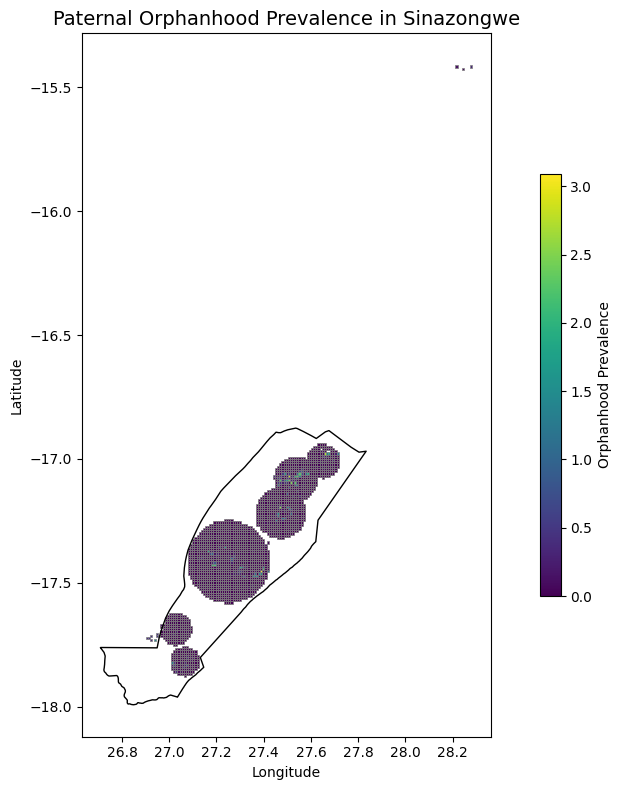

In [140]:

# Plot
fig, ax = plt.subplots(figsize=(10, 8))

map_data = map_data.set_geometry("geometry_original")

# Plot the orphanhood prevalence
map_data.plot(
    column='TEMP',        # Column with orphanhood prevalence
    cmap='viridis',          # Color map (Orange-Red gradient)
    linewidth=0.5,
    edgecolor='gray',
    legend=True,
    legend_kwds={'label': "Orphanhood Prevalence", 'shrink': 0.6},
    ax=ax
)

# Plot the boundary on top (optional for visual clarity)
boundary_gdf.boundary.plot(ax=ax, color='black', linewidth=1)

# Title and clean-up
ax.set_title("Paternal Orphanhood Prevalence in Sinazongwe", fontsize=14)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

# Save as PDF
plt.tight_layout()
plt.savefig("paternal_orphanhood_prevalence_map_1k_mlp.pdf", format='pdf', dpi=300)

# Show the plot
plt.show()

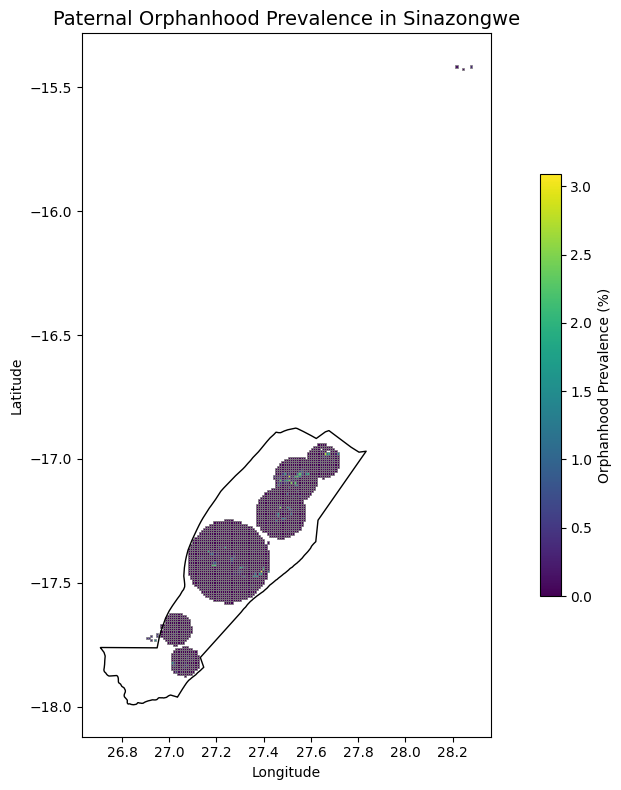

In [141]:
# map_data = map_data.drop(index=[316, 317, 318, 319]).reset_index(drop=True)

# Plot
fig, ax = plt.subplots(figsize=(10, 8))

map_data = map_data.set_geometry("geometry_original")

# Plot the orphanhood prevalence
map_data.plot(
    column='TEMP',        # Column with orphanhood prevalence
    cmap='viridis',          # Color map (Orange-Red gradient)
    linewidth=0.5,
    edgecolor='gray',
    legend=True,
    legend_kwds={'label': "Orphanhood Prevalence (%)", 'shrink': 0.6},
    ax=ax
)

# Plot the boundary on top (optional for visual clarity)
boundary_gdf.boundary.plot(ax=ax, color='black', linewidth=1)

# Title and clean-up
ax.set_title("Paternal Orphanhood Prevalence in Sinazongwe", fontsize=14)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

# Save as PDF
plt.tight_layout()
plt.savefig("paternal_orphanhood_prevalence_map_1k_mlp_2.pdf", format='pdf', dpi=300)

# Show the plot
plt.show()